# 02 Data Cleaning, Transformation, and Initial Analysis

## Task 1 — Where is my data now?

### What did I do with my data so far?

So far, I collected approximately 1,500 Europeana metadata records related to India using the Europeana API. The records were collected using four thematic query groups: geographic, colonial, cultural, and material. The dataset was saved as a CSV file and then copied into a raw data folder for preservation.

In the previous workflow step, I also created a deduplicated analytical subset based on unique titles. This reduced the dataset from 1,500 records to a smaller set of unique metadata titles for later analysis.

### What is the research question I have in mind?

The main research question is:

How is India represented in Europeana metadata, and which thematic frameworks dominate these representations?

The project focuses on metadata fields such as title, description, data provider, object type, country, and query group.

### What is a problem I have with my dataset that requires addressing?

The dataset contains some repeated titles, missing metadata fields, and possible false positives. One important issue is the ambiguity of the word “Indian,” which can refer to India but can also refer to Indigenous peoples of the Americas in some records.

Another issue is that the subject column is missing for many or all records, so the analysis needs to rely more on titles, descriptions, providers, types, countries, and query groups.

### What is the transformation of data required to proceed?

The next transformation is to create new columns that make the dataset easier to analyse. For example, I can create columns that show whether a record has a description, whether the title contains the word “India,” and whether a record may be a false positive.

I will also use the deduplicated dataset based on unique titles so that repeated titles do not dominate the analysis.

### What would I like to achieve with my data in today’s class?

Today I would like to prepare the dataset for analysis, create useful new variables, and produce a first visualisation. The visualisation should help show how India-related records are distributed by object type, query group, or possible thematic category.

## Repository check-in

### Dataset structure

The dataset is stored in the project repository under the `data/` folder. The raw dataset contains approximately 1,500 Europeana metadata records related to India. The processed dataset contains a deduplicated version based on unique titles.

Main files:

- `data/raw/europeana_india_dataset_1500_raw.csv`
- `data/processed/europeana_india_unique_titles.csv`

The main columns in the dataset are:

- `query_group`
- `search_term`
- `title`
- `description`
- `subject`
- `dataProvider`
- `type`
- `country`

### Already documented step

The first two workflow stages were documented in the notebook `01_data_access.ipynb`. This notebook loads the dataset, checks the query group distribution, saves a raw copy, creates a deduplicated analytical subset, and saves the processed file.

### Next step

The next step is to transform the processed dataset into a more analysable form. I will create new columns that describe metadata completeness and possible false positives, and then create a first visualisation to support the research question.

# Today's transformation and analysis goal

## Part of the dataset I will focus on

Today I will focus on the deduplicated dataset stored in:

`data/processed/europeana_india_unique_titles.csv`

I will mainly use the columns `title`, `description`, `type`, `query_group`, `dataProvider`, and `country`.

## Transformation goal

The transformation goal is to create new variables that make the dataset easier to analyse:

- `has_description`: shows whether a record has a description;
- `title_word_count`: counts the number of words in the title;
- `contains_india`: checks whether the title contains the word “India”;
- `possible_false_positive`: marks records that may refer to Native American or non-India-related uses of “Indian.”

The original processed dataset will not be overwritten. A new transformed file will be saved separately.

## Analysis and visualisation goal

The first analysis will examine the distribution of object types in the deduplicated dataset. I will create a bar chart showing how many records are images, texts, sounds, or videos.

This visualisation helps answer the research question because it shows which media formats dominate the representation of India in Europeana metadata.

In [1]:
# Import required libraries

import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# Define project folders

# This notebook is inside the notebooks folder,
# so the main project folder is one level above.
project_dir = Path.cwd().parent

data_dir = project_dir / "data"
processed_dir = data_dir / "processed"
outputs_dir = project_dir / "outputs"
figures_dir = outputs_dir / "figures"

# Create output folders if they do not already exist
outputs_dir.mkdir(exist_ok=True)
figures_dir.mkdir(exist_ok=True)

print("Current notebook folder:", Path.cwd())
print("Project folder:", project_dir)
print("Processed data folder:", processed_dir)
print("Figures folder:", figures_dir)

Current notebook folder: C:\Users\kevin\Documents\GitHub\Open_Project_2026\notebooks
Project folder: C:\Users\kevin\Documents\GitHub\Open_Project_2026
Processed data folder: C:\Users\kevin\Documents\GitHub\Open_Project_2026\data\processed
Figures folder: C:\Users\kevin\Documents\GitHub\Open_Project_2026\outputs\figures


In [3]:
# Load the deduplicated analytical dataset

input_file = processed_dir / "europeana_india_unique_titles.csv"

df = pd.read_csv(input_file)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully.
Shape: (245, 8)


,query_group,search_term,title,description,subject,dataProvider,type,country
0,geographic,India,India,"Barev.\n28 x 36 cm, na listu 38 x 43 cm\nMěřít...",NaN,Map Collection UK,IMAGE,['Czech Republic']
1,geographic,India,India.,"Litografie, kolor.\n28,5 x 37 cm na listu 31 x...",NaN,Map Collection UK,IMAGE,['Czech Republic']
2,geographic,India,%india%,NaN,NaN,Royal Museums Greenwich,IMAGE,['United Kingdom']
3,geographic,India,India & Nepál,"Tartalom ◊ I. ◊ Az első randevú: Delhi, 1972 ◊...",NaN,National Széchényi Library of Hungary,TEXT,['Hungary']
4,geographic,India,India SONG,NaN,NaN,National Audiovisual Institute France,SOUND,['France']


In [4]:
# Create new variables for analysis

df_transformed = df.copy()

# Check whether each record has a description
df_transformed["has_description"] = df_transformed["description"].notna()

# Count words in the title
df_transformed["title_word_count"] = (
    df_transformed["title"]
    .fillna("")
    .astype(str)
    .str.split()
    .str.len()
)

# Check whether the title contains "India"
df_transformed["contains_india"] = (
    df_transformed["title"]
    .fillna("")
    .astype(str)
    .str.contains("India", case=False, na=False)
)

# Mark possible false positives connected to non-India meanings of "Indian"
false_positive_terms = [
    "Indianer",
    "Kuna",
    "Apache",
    "Seminole",
    "Miccosukee",
    "Camacan",
    "Huichol",
    "Native American"
]

pattern = "|".join(false_positive_terms)

df_transformed["possible_false_positive"] = (
    df_transformed["title"]
    .fillna("")
    .astype(str)
    .str.contains(pattern, case=False, na=False)
)

print("Transformation completed.")
print("New columns added:")
print(["has_description", "title_word_count", "contains_india", "possible_false_positive"])

df_transformed.head(10)

Transformation completed.
New columns added:
['has_description', 'title_word_count', 'contains_india', 'possible_false_positive']


,query_group,search_term,title,description,subject,dataProvider,type,country,has_description,title_word_count,contains_india,possible_false_positive
0,geographic,India,India,"Barev.\n28 x 36 cm, na listu 38 x 43 cm\nMěřít...",NaN,Map Collection UK,IMAGE,['Czech Republic'],True,1,True,False
1,geographic,India,India.,"Litografie, kolor.\n28,5 x 37 cm na listu 31 x...",NaN,Map Collection UK,IMAGE,['Czech Republic'],True,1,True,False
2,geographic,India,%india%,NaN,NaN,Royal Museums Greenwich,IMAGE,['United Kingdom'],False,1,True,False
3,geographic,India,India & Nepál,"Tartalom ◊ I. ◊ Az első randevú: Delhi, 1972 ◊...",NaN,National Széchényi Library of Hungary,TEXT,['Hungary'],True,3,True,False
4,geographic,India,India SONG,NaN,NaN,National Audiovisual Institute France,SOUND,['France'],False,2,True,False
5,geographic,India,India (De),NaN,NaN,Marucelliana Library,TEXT,['Italy'],False,2,True,False
6,geographic,India,India orientalis,NaN,NaN,Marciana National Library,IMAGE,['Italy'],False,2,True,False
7,geographic,India,India orien.,NaN,NaN,University Library of Genova,IMAGE,['Italy'],False,2,True,False
8,geographic,India,India vetus,NaN,NaN,University Library of Genova,IMAGE,['Italy'],False,2,True,False
9,geographic,India,India Orientalis.,NaN,NaN,University Library of Genova,IMAGE,['Italy'],False,2,True,False


In [5]:
# Save transformed dataset

output_file = processed_dir / "europeana_india_unique_titles_transformed.csv"

df_transformed.to_csv(output_file, index=False, encoding="utf-8")

print("Transformed dataset saved to:")
print(output_file)

Transformed dataset saved to:
C:\Users\kevin\Documents\GitHub\Open_Project_2026\data\processed\europeana_india_unique_titles_transformed.csv


## First visualisation: Object type distribution

This visualisation shows which object types dominate the deduplicated Europeana India dataset. This is relevant to the research question because the form of the records affects how India is represented in the metadata.

Object type counts:
type
IMAGE    173
TEXT      57
VIDEO      8
SOUND      7
Name: count, dtype: int64


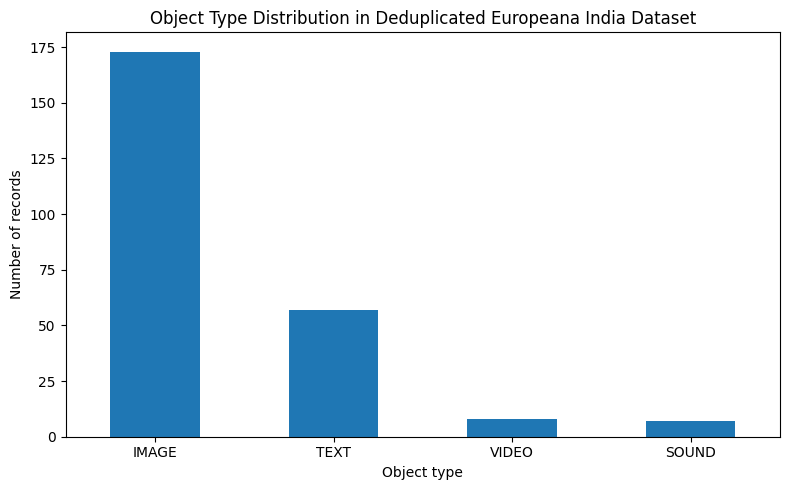

Figure saved to:
C:\Users\kevin\Documents\GitHub\Open_Project_2026\outputs\figures\object_type_distribution.png


In [6]:
# Count object types

type_counts = df_transformed["type"].value_counts()

print("Object type counts:")
print(type_counts)

# Create bar chart
plt.figure(figsize=(8, 5))
type_counts.plot(kind="bar")

plt.title("Object Type Distribution in Deduplicated Europeana India Dataset")
plt.xlabel("Object type")
plt.ylabel("Number of records")
plt.xticks(rotation=0)
plt.tight_layout()

# Save figure
figure_file = figures_dir / "object_type_distribution.png"
plt.savefig(figure_file, dpi=300)

plt.show()

print("Figure saved to:")
print(figure_file)

## Interpretation of the object type visualisation

The object type distribution shows that the deduplicated Europeana India dataset is mainly composed of image records, followed by text records, with only a small number of sound and video records.

This suggests that India is represented in Europeana primarily through visual cultural heritage materials. This is relevant to the research question because the dominance of image-based records may shape how India is represented: visual objects, photographs, maps, textiles, and museum images may be more visible than textual or audiovisual sources.

A limitation of this result is that it reflects the structure of Europeana metadata and the availability of digitised records, not necessarily the full range of India-related cultural heritage materials held by European institutions.

## Reproducibility check

This step checks whether the transformed dataset and the visualisation file were successfully created.

In [7]:
# Check whether output files were created successfully

print("Transformed data file exists:", output_file.exists())
print("Figure file exists:", figure_file.exists())

print("\nTransformed data file:")
print(output_file)

print("\nFigure file:")
print(figure_file)

Transformed data file exists: True
Figure file exists: True

Transformed data file:
C:\Users\kevin\Documents\GitHub\Open_Project_2026\data\processed\europeana_india_unique_titles_transformed.csv

Figure file:
C:\Users\kevin\Documents\GitHub\Open_Project_2026\outputs\figures\object_type_distribution.png


## Summary of this notebook

This notebook transformed the deduplicated Europeana India metadata dataset by creating new variables for metadata completeness, title length, India-related title references, and possible false positives.

The notebook then created a first visualisation showing the distribution of object types in the deduplicated dataset. The result suggests that India-related records in Europeana are mainly represented through image-based materials.

The transformed dataset was saved in `data/processed/`, and the visualisation was saved in `outputs/figures/`.